imports, seeds and device

In [1]:
import sys
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split


# Optional OpenCV
try:
    import cv2
    print("OpenCV:", cv2.__version__)
except ImportError:
    cv2 = None
    print("OpenCV not found (only needed for the optional photo test)")


# Fixed seed so results are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# Select the available device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


# Display environment information
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device)

OpenCV: 5.0.0
Python: 3.13.15
PyTorch: 2.14.1+cpu | torchvision: 0.29.1+cpu
Training on: cpu


datasets and data loaders

In [2]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']
MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
train_full = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=tf)
test_set = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf)
# 45,000 for training, 5,000 for validation
train_set, val_set = random_split(
train_full, [45000, 5000], generator=torch.Generator().manual_seed(SEED))
BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False, num_workers=2)
print("train / val / test sizes:", len(train_set), len(val_set), len(test_set))

train / val / test sizes: 45000 5000 10000


look at real images and class balance

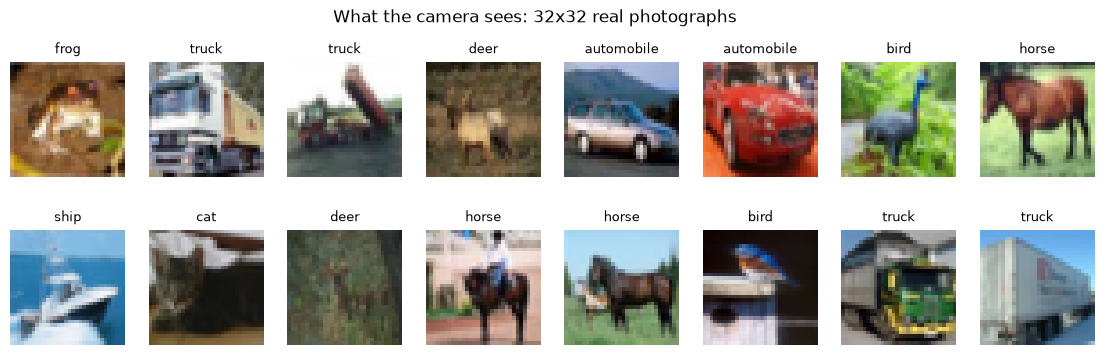

Images per class: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [3]:
raw = torchvision.datasets.CIFAR10(
    "./data",
    train=True,
    download=False
)  # PIL images

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for ax, i in zip(axes.flat, range(16)):
    img, label = raw[i]

    ax.imshow(img)

    ax.set_title(CLASSES[label], fontsize=9)

    ax.axis("off")

plt.suptitle("What the camera sees: 32x32 real photographs")

plt.show()

print(
    "Images per class:",
    dict(zip(CLASSES, np.bincount(raw.targets)))
)

inspect one batch

In [4]:
images, labels = next(iter(train_loader))
print("images:", images.shape, "| labels:", labels.shape)
print("pixel range after normalisation: %.2f to %.2f" % (images.min(), images.max()))

images: torch.Size([128, 3, 32, 32]) | labels: torch.Size([128])
pixel range after normalisation: -1.99 to 2.13


define the model

In [5]:
class SceneCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
            # Raw scores (logits), no softmax here
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Create the model and move it to the selected device
model = SceneCNN().to(device)

print(model)

SceneCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


trace the shapes

In [6]:
# Create one fake 32x32 RGB image
x = torch.randn(1, 3, 32, 32).to(device)

# Pass the image through each feature layer
for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:<10} -> {tuple(x.shape)}")

# Show the number of values after the final convolution/pooling layers
print("Flattened length fed to the classifier:", x.numel())

Conv2d     -> (1, 32, 32, 32)
ReLU       -> (1, 32, 32, 32)
MaxPool2d  -> (1, 32, 16, 16)
Conv2d     -> (1, 64, 16, 16)
ReLU       -> (1, 64, 16, 16)
MaxPool2d  -> (1, 64, 8, 8)
Conv2d     -> (1, 128, 8, 8)
ReLU       -> (1, 128, 8, 8)
MaxPool2d  -> (1, 128, 4, 4)
Flattened length fed to the classifier: 2048


how many weights? CNN vs plain fully-connected network

In [7]:
# Count the number of trainable parameters
def count_params(m):
    return sum(
        p.numel()
        for p in m.parameters()
        if p.requires_grad
    )


# Plain MLP for comparison
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)


# Compare the number of parameters
print(f"SceneCNN parameters : {count_params(model):>10,}")
print(f"Plain MLP parameters: {count_params(mlp):>10,}")
print()


# Show every trainable parameter in the CNN
for name, p in model.named_parameters():
    print(
        f"{name:<22}"
        f"{str(tuple(p.shape)):<20}"
        f"{p.numel():>9,}"
    )

SceneCNN parameters :    620,362
Plain MLP parameters:    789,258

features.0.weight     (32, 3, 3, 3)             864
features.0.bias       (32,)                      32
features.3.weight     (64, 32, 3, 3)         18,432
features.3.bias       (64,)                      64
features.6.weight     (128, 64, 3, 3)        73,728
features.6.bias       (128,)                    128
classifier.1.weight   (256, 2048)           524,288
classifier.1.bias     (256,)                    256
classifier.3.weight   (10, 256)               2,560
classifier.3.bias     (10,)                      10


receptive field of each layer

In [8]:
layers = [
    ("conv1", 3, 1),
    ("pool1", 2, 2),
    ("conv2", 3, 1),
    ("pool2", 2, 2),
    ("conv3", 3, 1),
    ("pool3", 2, 2)
]  # (name, kernel size, stride)

r, j = 1, 1

for name, k, s in layers:
    r = r + (k - 1) * j
    j = j * s

    print(
        f"{name}: each neuron sees a "
        f"{r} x {r} patch of the original image"
    )

conv1: each neuron sees a 3 x 3 patch of the original image
pool1: each neuron sees a 4 x 4 patch of the original image
conv2: each neuron sees a 8 x 8 patch of the original image
pool2: each neuron sees a 10 x 10 patch of the original image
conv3: each neuron sees a 18 x 18 patch of the original image
pool3: each neuron sees a 22 x 22 patch of the original image


loss sanity check and gradient inspection

In [9]:
# Loss function
criterion = nn.CrossEntropyLoss()


# Get one batch of training images and labels
images, labels = next(iter(train_loader))

# Move data to the selected device
images = images.to(device)
labels = labels.to(device)


# Clear any existing gradients
model.zero_grad()


# Forward pass + calculate loss
loss = criterion(model(images), labels)


# Backward pass (backpropagation)
loss.backward()


# Display the initial loss
print(
    f"Initial loss: {loss.item():.3f} "
    f"(guessing = ln(10) = {np.log(10):.3f})"
)


# Display gradient sizes for each weight parameter
for name, p in model.named_parameters():
    if "weight" in name:
        print(
            f"{name:<22} "
            f"gradient norm = {p.grad.norm().item():.4f}"
        )

Initial loss: 2.305 (guessing = ln(10) = 2.303)
features.0.weight      gradient norm = 0.0211
features.3.weight      gradient norm = 0.0654
features.6.weight      gradient norm = 0.1043
classifier.1.weight    gradient norm = 0.2348
classifier.3.weight    gradient norm = 0.0861


train 

In [10]:
# Number of training epochs
EPOCHS = 15 if device.type != "cpu" else 4  # Fewer epochs on CPU


# Optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.0001,
    momentum=0.9
)


# Function to run one training or validation epoch
def run_epoch(loader, train):
    model.train(train)

    total_loss = 0.0
    correct = 0
    n = 0

    with torch.set_grad_enabled(train):

        for x, y in loader:
            # Move data to the selected device
            x = x.to(device)
            y = y.to(device)

            # Forward pass
            out = model(x)

            # Calculate cross-entropy loss
            loss = criterion(out, y)

            if train:
                # Clear previous gradients
                optimizer.zero_grad()

                # Backpropagation
                loss.backward()

                # Update model parameters
                optimizer.step()

            # Accumulate loss
            total_loss += loss.item() * x.size(0)

            # Count correct predictions
            correct += (out.argmax(1) == y).sum().item()

            # Count total samples
            n += x.size(0)

    return total_loss / n, correct / n


# ============================================================
# Training history
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}


# ============================================================
# Training loop
# ============================================================

for epoch in range(1, EPOCHS + 1):

    t0 = time.time()

    # Training
    tl, ta = run_epoch(train_loader, train=True)

    # Validation
    vl, va = run_epoch(val_loader, train=False)

    # Save results
    for k, v in zip(
        history,
        (tl, vl, ta, va)
    ):
        history[k].append(v)

    # Display results
    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train loss {tl:.3f} acc {ta:.1%} | "
        f"val loss {vl:.3f} acc {va:.1%} | "
        f"{time.time() - t0:.0f}s"
    )

Epoch 1/4 | train loss 2.300 acc 11.8% | val loss 2.297 acc 14.1% | 206s
Epoch 2/4 | train loss 2.295 acc 14.0% | val loss 2.292 acc 13.8% | 171s
Epoch 3/4 | train loss 2.290 acc 12.9% | val loss 2.286 acc 13.4% | 167s
Epoch 4/4 | train loss 2.283 acc 13.7% | val loss 2.279 acc 13.9% | 164s


plot the learning curves and save the model

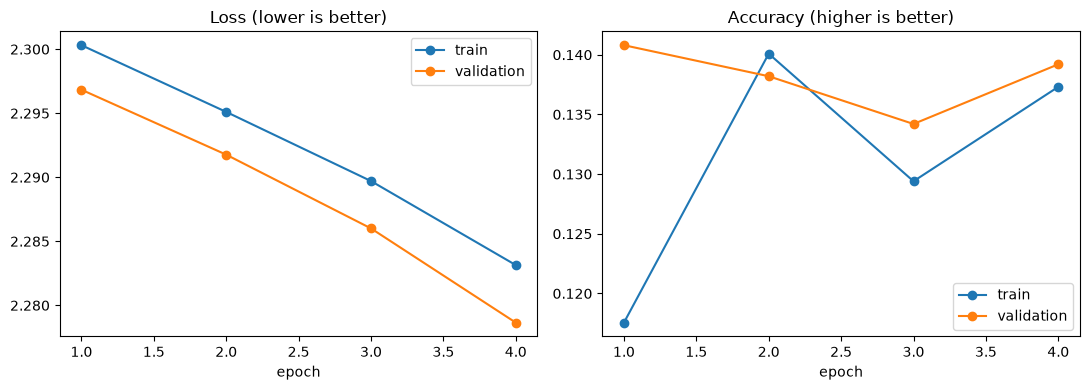

In [11]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, history["train_loss"], "o-", label="train")
ax[0].plot(epochs, history["val_loss"], "o-", label="validation")
ax[0].set_title("Loss (lower is better)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, history["train_acc"], "o-", label="train")
ax[1].plot(epochs, history["val_acc"], "o-", label="validation")
ax[1].set_title("Accuracy (higher is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
torch.save(model.state_dict(), "scene_cnn_week3.pth")

test accuracy, per-class accuracy and confusion matrix

Test accuracy: 14.33%

Per-class accuracy:
airplane   0.0%
automobile 40.0%
bird       0.0%
cat        0.4%
deer       0.0%
dog        2.3%
frog       1.1%
horse      28.0%
ship       0.0%
truck      71.5%


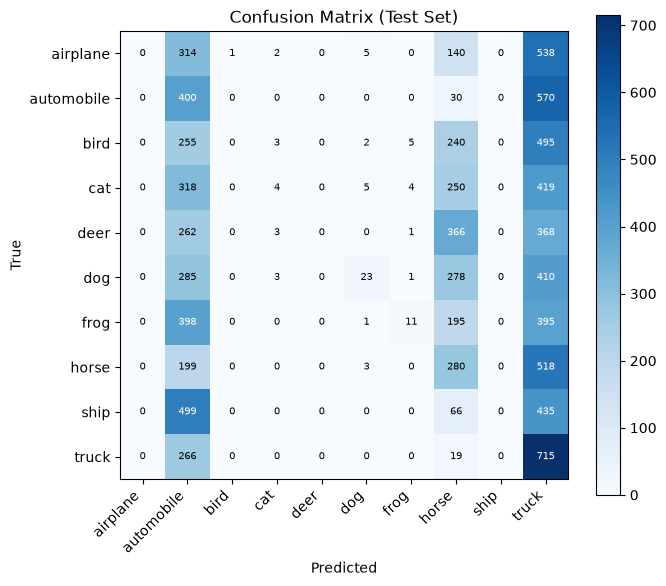


Three most common mistakes:
 automobile predicted as truck: 570 times
 airplane predicted as truck: 538 times
 horse predicted as truck: 518 times


In [12]:
# ============================================================
# 1. Get predictions for the entire dataset
# ============================================================

@torch.no_grad()
def predict_all(loader):
    model.eval()

    probs = []
    ys = []

    for x, y in loader:
        # Get model predictions
        output = model(x.to(device))

        # Convert logits to probabilities
        probs.append(
            F.softmax(output, dim=1).cpu()
        )

        # Store true labels
        ys.append(y)

    return torch.cat(probs), torch.cat(ys)


# ============================================================
# 2. Predict on the test set
# ============================================================

probs, ys = predict_all(test_loader)

# Get predicted class
preds = probs.argmax(1)

# Calculate test accuracy
accuracy = (preds == ys).float().mean()

print(f"Test accuracy: {accuracy:.2%}\n")


# ============================================================
# 3. Build confusion matrix
# ============================================================

# Rows = true class
# Columns = predicted class
cm = np.zeros((10, 10), dtype=int)

for t, p_ in zip(ys.numpy(), preds.numpy()):
    cm[t, p_] += 1


# ============================================================
# 4. Display accuracy for each class
# ============================================================

print("Per-class accuracy:")

for c, a in zip(
    CLASSES,
    cm.diagonal() / cm.sum(1)
):
    print(f"{c:<11}{a:.1%}")


# ============================================================
# 5. Plot confusion matrix
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(10))
ax.set_xticklabels(
    CLASSES,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(10))
ax.set_yticklabels(CLASSES)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Test Set)")


# Add numbers inside each cell
for i in range(10):
    for j in range(10):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=7,
            color=(
                "white"
                if cm[i, j] > cm.max() / 2
                else "black"
            )
        )


plt.colorbar(im)
plt.tight_layout()
plt.show()


# ============================================================
# 6. Find the three most common mistakes
# ============================================================

# Make a copy of the confusion matrix
off = cm.copy()

# Remove correct predictions from the diagonal
np.fill_diagonal(off, 0)

print("\nThree most common mistakes:")

for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)

    print(
        f" {CLASSES[t]} predicted as "
        f"{CLASSES[p_]}: {off[t, p_]} times"
    )

the model's most confident mistakes

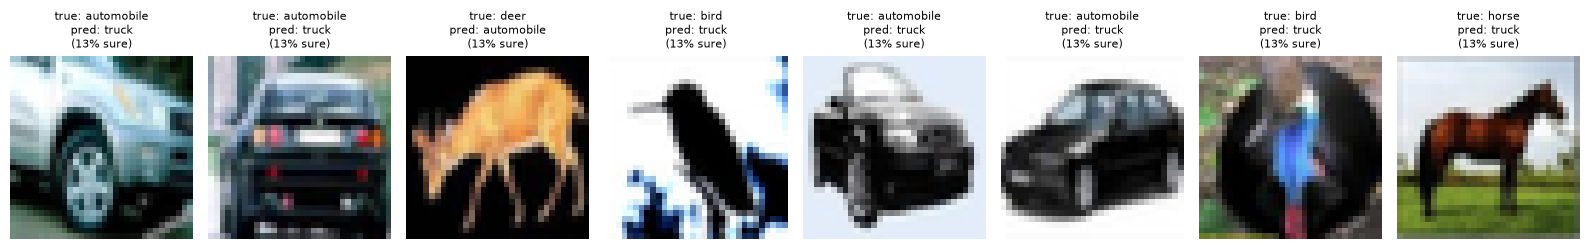

In [13]:
# ============================================================
# Find the most confident wrong predictions
# ============================================================

# Get the confidence of the predicted class
conf, _ = probs.max(1)

# Find all incorrectly classified images
wrong = (preds != ys).nonzero().flatten()

# Select the 8 incorrect predictions with the highest confidence
worst = wrong[
    conf[wrong].argsort(descending=True)[:8]
]


# ============================================================
# Load the raw CIFAR-10 test images
# ============================================================

raw_test = torchvision.datasets.CIFAR10(
    "./data",
    train=False,
    download=False
)


# ============================================================
# Display the 8 most confident mistakes
# ============================================================

fig, axes = plt.subplots(
    1,
    8,
    figsize=(16, 3)
)

for ax, idx in zip(axes, worst.tolist()):

    # Get the original PIL image
    img, _ = raw_test[idx]

    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"true: {CLASSES[ys[idx]]}\n"
        f"pred: {CLASSES[preds[idx]]}\n"
        f"({conf[idx]:.0%} sure)",
        fontsize=8
    )


plt.tight_layout()
plt.show()

object-level vs scene-level accuracy

In [14]:
VEHICLES = torch.tensor([0, 1, 8, 9]) # airplane, automobile, ship, truck
true_vehicle = torch.isin(ys, VEHICLES)
pred_vehicle = torch.isin(preds, VEHICLES)
print(f"10-class (object-level) accuracy : {(preds == ys).float().mean():.2%}")
print(f"Vehicle vs animal (scene-level) : {(true_vehicle == pred_vehicle).float().mean():.2%}")

10-class (object-level) accuracy : 14.33%
Vehicle vs animal (scene-level) : 54.15%


does the formula match PyTorch?

In [15]:
def out_size(h, k, p, s):
    return (h + 2 * p - k) // s + 1


for k, p_, s in [
    (3, 0, 1),
    (3, 0, 2),
    (3, 1, 1),
    (3, 1, 2)
]:
    real = nn.Conv2d(
        3,
        8,
        kernel_size=k,
        padding=p_,
        stride=s
    )(torch.randn(1, 3, 32, 32))

    print(
        f"kernel={k} padding={p_} stride={s}: "
        f"formula {out_size(32, k, p_, s)}"
        f" | PyTorch {real.shape[-1]}"
    )

kernel=3 padding=0 stride=1: formula 30 | PyTorch 30
kernel=3 padding=0 stride=2: formula 15 | PyTorch 15
kernel=3 padding=1 stride=1: formula 32 | PyTorch 32
kernel=3 padding=1 stride=2: formula 16 | PyTorch 16


too large, just right, too small

In [16]:
# ============================================================
# 1. Create a smaller training subset
# ============================================================

sub_loader = DataLoader(
    Subset(train_set, range(10000)),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2
)


# ============================================================
# 2. Quick learning-rate test
# ============================================================

def quick_lr_test(lr, epochs=2):

    # Reset the random seed so each learning rate
    # starts with the same model initialization
    torch.manual_seed(SEED)

    # Create a fresh model
    m = SceneCNN().to(device)

    # Create optimizer
    opt = torch.optim.SGD(
        m.parameters(),
        lr=lr,
        momentum=0.9
    )

    # Training
    for _ in range(epochs):

        m.train()

        for x, y in sub_loader:

            x = x.to(device)
            y = y.to(device)

            # Clear previous gradients
            opt.zero_grad()

            # Forward pass + loss
            loss = criterion(m(x), y)

            # Backpropagation
            loss.backward()

            # Update weights
            opt.step()


    # ========================================================
    # Validation
    # ========================================================

    m.eval()

    correct = 0

    with torch.no_grad():

        for x, y in val_loader:

            predictions = m(
                x.to(device)
            ).argmax(1).cpu()

            correct += (
                predictions == y
            ).sum().item()


    val_acc = correct / len(val_set)

    return loss.item(), val_acc


# ============================================================
# 3. Test different learning rates
# ============================================================

# My prediction: lr = 0.01 should work well

for lr in [0.1, 0.01, 0.001]:

    last_loss, val_acc = quick_lr_test(lr)

    print(
        f"lr = {lr:<6} "
        f"final batch loss = {last_loss:.3f} "
        f"validation accuracy = {val_acc:.1%}"
    )

lr = 0.1    final batch loss = 1.466 validation accuracy = 39.6%
lr = 0.01   final batch loss = 1.728 validation accuracy = 38.6%
lr = 0.001  final batch loss = 2.299 validation accuracy = 12.4%


predict a real photo

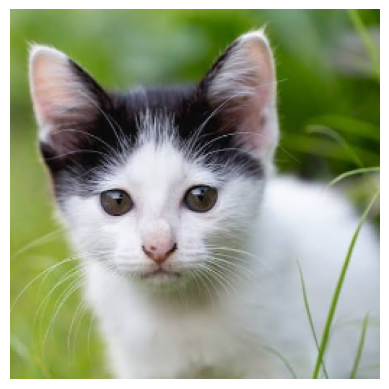

Predictions:
horse      11.4%
truck      10.5%
dog        10.5%


In [17]:
def predict_photo(path, topk=3):

    # ========================================================
    # 1. Read the image
    # ========================================================

    bgr = cv2.imread(path)

    if bgr is None:
        raise FileNotFoundError(path)


    # ========================================================
    # 2. Convert BGR to RGB
    # ========================================================

    rgb = cv2.cvtColor(
        bgr,
        cv2.COLOR_BGR2RGB
    )


    # ========================================================
    # 3. Center-crop the image to a square
    # ========================================================

    h, w = rgb.shape[:2]
    s = min(h, w)

    rgb = rgb[
        (h - s) // 2:(h - s) // 2 + s,
        (w - s) // 2:(w - s) // 2 + s
    ]


    # ========================================================
    # 4. Resize to CIFAR-10 size: 32 x 32
    # ========================================================

    small = cv2.resize(
        rgb,
        (32, 32),
        interpolation=cv2.INTER_AREA
    )


    # ========================================================
    # 5. Convert image to PyTorch tensor
    # ========================================================

    x = torch.from_numpy(small)

    # H x W x C  →  C x H x W
    x = x.permute(2, 0, 1)

    # Convert pixel values from 0-255 to 0-1
    x = x.float() / 255.0


    # ========================================================
    # 6. Normalize the image
    # ========================================================

    x = T.Normalize(
        MEAN,
        STD
    )(x)

    # Add batch dimension
    x = x.unsqueeze(0).to(device)


    # ========================================================
    # 7. Make prediction
    # ========================================================

    model.eval()

    with torch.no_grad():

        probabilities = F.softmax(
            model(x),
            dim=1
        )[0].cpu()


    # Get top-k predictions
    top = probabilities.topk(topk)


    # ========================================================
    # 8. Display the image
    # ========================================================

    plt.imshow(
        cv2.resize(rgb, (256, 256))
    )

    plt.axis("off")
    plt.show()


    # ========================================================
    # 9. Display predictions
    # ========================================================

    print("Predictions:")

    for score, i in zip(
        top.values,
        top.indices
    ):
        print(
            f"{CLASSES[i]:<11}"
            f"{score:.1%}"
        )


# ============================================================
# 10. Test with your own photo
# ============================================================

predict_photo("../images/sample.jpg")